In [12]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from src.clustering import get_wcss_scores, apply_optimized_kmeans
from src.clustering import identify_optimal_k, apply_optimized_kmeans
from src.clustering import get_tournament_k_values, apply_k_tournament,print_cluster_summary

Calculating WCSS for K=1 to K=10...


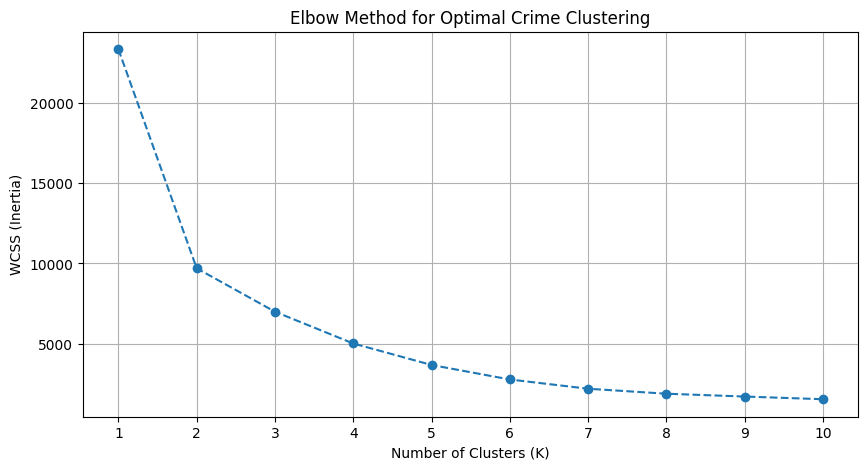

In [13]:
df = pd.read_csv('../data/Crime_Data_from_2020_to_Present_Cleaned.csv')

print("Calculating WCSS for K=1 to K=10...")
wcss = get_wcss_scores(df)

# Plot the results to find the optimal value
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Crime Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [14]:
# Automatically identify the K value
optimal_k, wcss_values = identify_optimal_k(df)

# Print the result 
print(f"Automated Geospatial Analysis")
print(f"The Mathematical Elbow Point identified: K = {optimal_k}")
print(f"Reasoning: Maximum curvature detected in WCSS at K={optimal_k}.")

# 3. Use the dynamic value to cluster the data
df_final, kmeans_model = apply_optimized_kmeans(df, optimal_k)

Automated Geospatial Analysis
The Mathematical Elbow Point identified: K = 2
Reasoning: Maximum curvature detected in WCSS at K=2.


In [15]:
# 1. Dynamically identify the comparison points
k_values, wcss_history = get_tournament_k_values(df)

print(f"Tournament Candidates Identified")
print(f"Primary Elbow (Mathematical): K = {k_values[0]}")
print(f"Operational Candidate (Granular): K = {k_values[1]}")

# 2. Generate and save both experiment files
experiment_data = apply_k_tournament(df, k_values)

for k, data in experiment_data.items():
    path = f'../data/Crime_Data_K{k}.csv'
    data.to_csv(path, index=False)
    print(f"Saved experiment dataset to: {path}")

Tournament Candidates Identified
Primary Elbow (Mathematical): K = 2
Operational Candidate (Granular): K = 4
Saved experiment dataset to: ../data/Crime_Data_K2.csv
Saved experiment dataset to: ../data/Crime_Data_K4.csv


In [16]:
# k model summary for k=2 
kmodel_summary_k2 = print_cluster_summary(experiment_data[k_values[1]], k_values[1])

# k model summary for k=4
kmodel_summary_k4 = print_cluster_summary(experiment_data[k_values[0]], k_values[0])


--- 4 Statistics ---
   cluster_id  Total_Crimes  Percentage
0           0        463239       46.20
1           1        275330       27.46
2           2         43682        4.36
3           3        220500       21.99

--- 2 Statistics ---
   cluster_id  Total_Crimes  Percentage
0           0        695485       69.36
1           1        307266       30.64
